In [1]:
!pip install numpy pandas matplotlib scikit-learn tensorflow requests


Defaulting to user installation because normal site-packages is not writeable


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import requests

from datetime import datetime, timedelta

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# from google.colab import drive
# drive.mount('/content/drive')


In [ ]:
# Location: Coimbatore
LATITUDE = 12.52
LONGITUDE = 78.22

PAST_DAYS = 365          # 1 year
SEQ_HOURS = 24           # 24-hour window

# CSV_PATH = "hourly_water_quality_1year.csv"
# Example path (adjust "My Drive/YourFolderName" to your actual folder name)
CSV_PATH = '/models/area_wise/area_wise_csv/karishnagiri.csv'


RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


In [40]:
def fetch_hourly_weather(lat, lon, past_days):
    end_date = datetime.utcnow().date()
    start_date = end_date - timedelta(days=past_days)

    url = (
        "https://archive-api.open-meteo.com/v1/archive?"
        f"latitude={lat}&longitude={lon}"
        f"&start_date={start_date}&end_date={end_date}"
        "&hourly=temperature_2m,relativehumidity_2m,precipitation"
        "&timezone=UTC"
    )

    data = requests.get(url).json()

    df = pd.DataFrame({
        "datetime": pd.to_datetime(data["hourly"]["time"]),
        "air_temp": data["hourly"]["temperature_2m"],
        "humidity": data["hourly"]["relativehumidity_2m"],
        "rain": data["hourly"]["precipitation"]
    })

    return df


In [41]:
def compute_water_quality(df):
    wt, do, ph = [], [], []
    prev_tw = None

    for _, r in df.iterrows():
        # --- Water temperature ---
        tw = r.air_temp - 1 if prev_tw is None else 0.7 * prev_tw + 0.3 * (r.air_temp - 1)

        # --- Dissolved Oxygen ---
        d = (14.6 - 0.2 * tw) * (1 + (r.humidity - 50) / 500)
        d = np.clip(d, 2, 14)

        # --- pH ---
        hour = r.datetime.hour
        p = (
            7.4
            + 0.3 * math.sin(2 * math.pi * hour / 24)
            - 0.01 * (tw - 26)
            - 0.08 * math.log1p(r.rain)
            + np.random.normal(0, 0.1)
        )
        p = np.clip(p, 6.5, 9.0)

        wt.append(round(tw, 2))
        do.append(round(d, 2))
        ph.append(round(p, 2))

        prev_tw = tw

    df["water_temp"] = wt
    df["do"] = do
    df["ph"] = ph
    return df


In [42]:
df_weather = fetch_hourly_weather(LATITUDE, LONGITUDE, PAST_DAYS)
df_water = compute_water_quality(df_weather)

df_water.to_csv(CSV_PATH, index=False)
print(" Dataset saved:", CSV_PATH)

df_water.head()


 Dataset saved: ../water_qual_pred/models/area_wise/area_wise_csv/karishnagiri.csv


,datetime,air_temp,humidity,rain,water_temp,do,ph
0,2025-03-08 00:00:00,16.5,75,0.0,15.50,12.08,7.55
1,2025-03-08 01:00:00,17.6,76,0.0,15.83,12.03,7.57
2,2025-03-08 02:00:00,19.6,69,0.0,16.66,11.70,7.71
3,2025-03-08 03:00:00,23.4,56,0.0,18.38,11.05,7.84
4,2025-03-08 04:00:00,26.3,48,0.0,20.46,10.47,7.69


In [19]:
# CSV_PATH = 'tn_aquaculture_data.csv'
# df = pd.read_csv(CSV_PATH, parse_dates=["datetime"])




In [ ]:
CSV_PATH = '/models/area_wise/area_wise_csv/karishnagiri.csv'
df = pd.read_csv(CSV_PATH, parse_dates=["datetime"])

FEATURES = ["air_temp", "humidity", "rain", "water_temp", "do", "ph"]
TARGETS = ["water_temp", "do", "ph"]

scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[FEATURES])

In [45]:
X, y = [], []

for i in range(len(scaled) - SEQ_HOURS):
    X.append(scaled[i:i + SEQ_HOURS])
    y.append(scaled[i + SEQ_HOURS][3:])  # water params only

X, y = np.array(X), np.array(y)


In [46]:
train_end = int(0.7 * len(X))
val_end = int(0.85 * len(X))

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val     = X[train_end:val_end], y[train_end:val_end]
X_test, y_test   = X[val_end:], y[val_end:]

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)


Train: (6132, 24, 6)
Val  : (1314, 24, 6)
Test : (1314, 24, 6)


In [47]:
model = Sequential([
    LSTM(64, input_shape=(SEQ_HOURS, X.shape[2])),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(3)
])

model.compile(optimizer="adam", loss="mse")
model.summary()


C:\Users\Admin\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,355 (79.51 KB)

 Trainable params: 20,355 (79.51 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)


Epoch 1/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0235 - val_loss: 0.0082
Epoch 2/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0058 - val_loss: 0.0051
Epoch 3/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0048 - val_loss: 0.0035
Epoch 4/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0043 - val_loss: 0.0034
Epoch 5/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0039 - val_loss: 0.0033
Epoch 6/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0037 - val_loss: 0.0031
Epoch 7/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0034 - val_loss: 0.0028
Epoch 8/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0033 - val_loss: 0.0029
Epoch 9/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0032 - val_loss: 0.0029
Epoch 10/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0030 - val_loss: 0.0031
Epoch 11/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0029 - val_loss: 0.0029
Epoch 12/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
save_path = '/models/area_wise/area_wise_models/krishnagiri.keras'

model.save(save_path)
print(f"Model successfully saved to: {save_path}")

Model successfully saved to: ../water_qual_pred/models/area_wise/area_wise_models/krishnagiri.keras


In [ ]:
###############################################################################################
#metrics

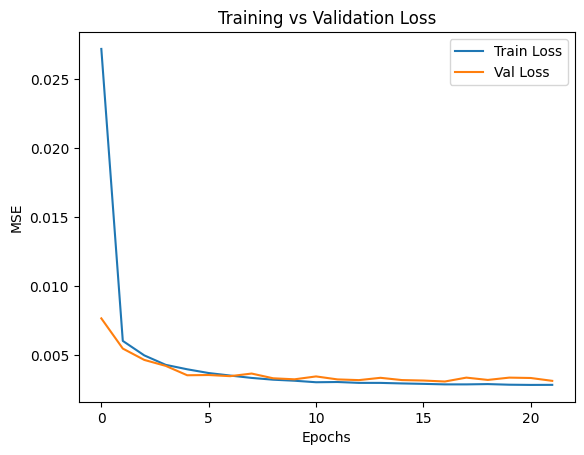

In [34]:
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()


In [35]:
y_pred = model.predict(X_test)

print("TEST SET PERFORMANCE")
print("Water Temp RMSE:", np.sqrt(mean_squared_error(y_test[:,0], y_pred[:,0])))
print("DO RMSE        :", np.sqrt(mean_squared_error(y_test[:,1], y_pred[:,1])))
print("pH RMSE        :", np.sqrt(mean_squared_error(y_test[:,2], y_pred[:,2])))

print("Water Temp MAE:", mean_absolute_error(y_test[:,0], y_pred[:,0]))
print("DO MAE        :", mean_absolute_error(y_test[:,1], y_pred[:,1]))
print("pH MAE        :", mean_absolute_error(y_test[:,2], y_pred[:,2]))


42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
TEST SET PERFORMANCE
Water Temp RMSE: 0.02538363841431522
DO RMSE        : 0.03617044783730307
pH RMSE        : 0.09178240159004035
Water Temp MAE: 0.01982120592586644
DO MAE        : 0.02724315836942475
pH MAE        : 0.07310298900997983


In [36]:
def predict_for_datetime(dt_time):
    dt = pd.to_datetime(dt_time)

    past = df[df.datetime < dt].tail(SEQ_HOURS)
    if len(past) < SEQ_HOURS:
        raise ValueError("Not enough historical data")

    X_in = scaler.transform(past[FEATURES]).reshape(1, SEQ_HOURS, len(FEATURES))
    pred_scaled = model.predict(X_in)[0]

    dummy = scaler.transform(past[FEATURES].iloc[-1:].values)
    dummy[0, 3:] = pred_scaled

    out = scaler.inverse_transform(dummy)[0]

    return {
        "predicted_water_temp": round(out[3], 2),
        "predicted_do": round(out[4], 2),
        "predicted_ph": round(out[5], 2)
    }


In [37]:
predict_for_datetime("2025-12-23 14:00")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


C:\Users\Admin\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


{'predicted_water_temp': np.float64(27.78),
 'predicted_do': np.float64(9.35),
 'predicted_ph': np.float64(7.23)}

In [38]:
SAFE_RANGES = {
    'water_temp': {'min': 25.0, 'max': 32.0, 'unit': 'C'},
    'do': {'min': 5.0, 'max': 14.0, 'unit': 'mg/L'},
    'ph': {'min': 6.5, 'max': 9.0, 'unit': ''}
}

def predict_for_datetime(target_dt_str):
    target_dt = pd.to_datetime(target_dt_str)
    last_available_dt = df['datetime'].iloc[-1]

    if target_dt <= last_available_dt:
        past = df[df.datetime < target_dt].tail(SEQ_HOURS)

        if len(past) < SEQ_HOURS:
            return "Error: Not enough historical data"

        X_in = scaler.transform(past[FEATURES]).reshape(1, SEQ_HOURS, len(FEATURES))
        pred_scaled = model.predict(X_in, verbose=0)[0]

        dummy = np.zeros((1, len(FEATURES)))
        dummy[0, 3:] = pred_scaled
        out = scaler.inverse_transform(dummy)[0]

        return {
            "type": "Historical",
            "water_temp": round(out[3], 2),
            "do": round(out[4], 2),
            "ph": round(out[5], 2)
        }

    else:
        current_seq = df[FEATURES].tail(SEQ_HOURS).values
        current_seq_scaled = scaler.transform(current_seq)

        time_diff = (target_dt - last_available_dt).total_seconds() / 3600
        steps_to_predict = int(time_diff)

        if steps_to_predict > 720:
             return "Error: Target date is too far in the future"

        last_pred = None

        for _ in range(steps_to_predict):
            X_in = current_seq_scaled.reshape(1, SEQ_HOURS, len(FEATURES))
            pred_scaled = model.predict(X_in, verbose=0)[0]

            last_weather_scaled = current_seq_scaled[-1][:3]
            new_row_scaled = np.concatenate([last_weather_scaled, pred_scaled])
            current_seq_scaled = np.vstack([current_seq_scaled[1:], new_row_scaled])

            last_pred = pred_scaled

        dummy = np.zeros((1, len(FEATURES)))
        dummy[0, 3:] = last_pred
        final_values = scaler.inverse_transform(dummy)[0]

        return {
            "type": "Future Forecast",
            "water_temp": round(final_values[3], 2),
            "do": round(final_values[4], 2),
            "ph": round(final_values[5], 2)
        }

def predict_with_alerts(dt_str):
    try:
        prediction = predict_for_datetime(dt_str)
    except Exception as e:
        return f"Prediction Error: {e}"

    if isinstance(prediction, str):
        return prediction

    print(f"Prediction for {dt_str}")
    print(f"Type: {prediction.get('type', 'Unknown')}")

    alerts = []

    for param in ['water_temp', 'do', 'ph']:
        val = prediction.get(param)
        safe_min = SAFE_RANGES[param]['min']
        safe_max = SAFE_RANGES[param]['max']
        unit = SAFE_RANGES[param]['unit']

        print(f"{param}: {val} {unit}")

        if val < safe_min:
            alerts.append(f"ALERT: {param} is TOO LOW ({val} < {safe_min})")
        elif val > safe_max:
             alerts.append(f"ALERT: {param} is TOO HIGH ({val} > {safe_max})")

    if alerts:
        print("\nSAFETY ALERT")
        for alert in alerts:
            print(alert)
        print("Action Required: Check aeration or adjust flow.")
    else:
        print("\nAll parameters are within the safe ideal range.")

predict_with_alerts("2025-12-23 14:00")

Prediction for 2025-12-23 14:00
Type: Historical
water_temp: 27.78 C
do: 9.35 mg/L
ph: 7.23 

All parameters are within the safe ideal range.


In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import numpy as np

y_pred_scaled = model.predict(X_test, verbose=0)

dummy_pred = np.zeros((len(y_pred_scaled), 6))
dummy_test = np.zeros((len(y_test), 6))

dummy_pred[:, 3:] = y_pred_scaled
dummy_test[:, 3:] = y_test

y_pred_real = scaler.inverse_transform(dummy_pred)[:, 3:]
y_test_real = scaler.inverse_transform(dummy_test)[:, 3:]

def print_metrics(name, y_true, y_pred, unit):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    print(f"\n{name} Performance:")
    print(f"   MAE  (Mean Absolute Error):       {mae:.4f} {unit}")
    print(f"   RMSE (Root Mean Squared Error):   {rmse:.4f} {unit}")
    print(f"   MAPE (Mean Abs % Error):          {mape:.2f} %")
    print(f"   R2 Score (Accuracy Fit):          {r2:.4f}")

print("-" * 50)
print("MODEL ACCURACY REPORT (Test Set)")
print("-" * 50)

print_metrics("Water Temperature", y_test_real[:, 0], y_pred_real[:, 0], "C")
print_metrics("Dissolved Oxygen",  y_test_real[:, 1], y_pred_real[:, 1], "mg/L")
print_metrics("pH Level",          y_test_real[:, 2], y_pred_real[:, 2], "")



--------------------------------------------------
MODEL ACCURACY REPORT (Test Set)
--------------------------------------------------

Water Temperature Performance:
   MAE  (Mean Absolute Error):       0.2094 C
   RMSE (Root Mean Squared Error):   0.2669 C
   MAPE (Mean Abs % Error):          0.87 %
   R2 Score (Accuracy Fit):          0.9825

Dissolved Oxygen Performance:
   MAE  (Mean Absolute Error):       0.0727 mg/L
   RMSE (Root Mean Squared Error):   0.0956 mg/L
   MAPE (Mean Abs % Error):          0.71 %
   R2 Score (Accuracy Fit):          0.9774

pH Level Performance:
   MAE  (Mean Absolute Error):       0.0883 
   RMSE (Root Mean Squared Error):   0.1111 
   MAPE (Mean Abs % Error):          1.19 %
   R2 Score (Accuracy Fit):          0.7694


In [19]:
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

y_pred_scaled = model.predict(X_test, verbose=0)

dummy_pred = np.zeros((len(y_pred_scaled), 6))
dummy_test = np.zeros((len(y_test), 6))

dummy_pred[:, 3:] = y_pred_scaled
dummy_test[:, 3:] = y_test

y_pred_real = scaler.inverse_transform(dummy_pred)[:, 3:]
y_test_real = scaler.inverse_transform(dummy_test)[:, 3:]

mape_temp = mean_absolute_percentage_error(y_test_real[:, 0], y_pred_real[:, 0])
mape_do = mean_absolute_percentage_error(y_test_real[:, 1], y_pred_real[:, 1])
mape_ph = mean_absolute_percentage_error(y_test_real[:, 2], y_pred_real[:, 2])

acc_temp = 100 - (mape_temp * 100)
acc_do = 100 - (mape_do * 100)
acc_ph = 100 - (mape_ph * 100)

overall_accuracy = (acc_temp + acc_do + acc_ph) / 3

print(f"Overall Model Accuracy: {overall_accuracy:.2f}%")

Overall Model Accuracy: 99.08%
